# Deep Convolutional GAN - Versione Avanzata

## Introduzione Teorica

Le **Generative Adversarial Networks (GAN)** sono un'architettura di deep learning con due reti neurali, un Generator e un Discriminator che competono tra loro per creare dati sintetici realistici (immagini, audio, testo), introdotta da Ian Goodfellow nel 2014:
- **Generator (G)**: impara a generare dati sintetici partendo da rumore casuale
- **Discriminator (D)**: impara a distinguere dati reali da dati generati

### Da GAN a DCGAN

Le **Deep Convolutional GAN (DCGAN)** di Radford et al. (2015) hanno introdotto linee guida architetturali che stabilizzano il training:

1. Sostituire pooling con convoluzioni strided (D) e convoluzioni trasposte (G)
2. Usare Batch Normalization in entrambe le reti
3. Rimuovere i layer fully-connected per architetture più profonde
4. Usare ReLU nel Generator (tranne l'output: Tanh) e LeakyReLU nel Discriminator

### Problemi delle GAN Vanilla e Soluzioni Avanzate

Le GAN soffrono di diversi problemi durante il training:

| Problema | Descrizione | Soluzione in questo notebook |
|----------|-------------|------------------------------|
| **Mode Collapse** | G genera solo poche varianti | Spectral Norm, DiffAugment |
| **Training Instability** | Oscillazioni e divergenza | Hinge Loss, R1 Penalty, TTUR |
| **Vanishing Gradients** | D troppo forte → gradienti nulli per G | Instance Noise, LR bilanciato |
| **Overfitting del D** | D memorizza il dataset | DiffAugment |

---

## Miglioramenti Implementati

### 1. Architettura della Rete
- **Spectral Normalization** nel Discriminator per controllare la costante di Lipschitz
- **Self-Attention Layer** per catturare dipendenze spaziali a lungo raggio
- **Residual Connections** nel Generator per migliorare il flusso dei gradienti

### 2. Funzione di Loss
- **Hinge Loss** invece di BCE (più stabile con Spectral Norm)

### 3. Tecniche di Training
- **Mixed Precision (AMP)** per velocizzare il training
- **Instance Noise** decrescente per stabilizzare il training iniziale
- **Two-Timescale Update Rule (TTUR)** - learning rate diversi per D e G
- **R1 Gradient Penalty** per prevenire che D diventi troppo sicuro
- **DiffAugment** per prevenire overfitting del Discriminator

### 4. Dataset ([Oxford Flowers 102](https://www.kaggle.com/datasets/waseemalastal/the-oxford-flowers-102-dataset))
- Utilizzo di **tutti gli split** (train + val + test) per massimizzare i dati
- **Data Augmentation** on-the-fly

## Librerie e Dipendenze

Per implementare una DCGAN avanzata abbiamo bisogno di diversi componenti software:

### PyTorch Core
- **`torch`**: il framework di deep learning, fornisce tensori GPU-accelerati e autograd
- **`torch.nn`**: moduli per costruire reti neurali (Conv2d, BatchNorm, etc.)
- **`torch.optim`**: ottimizzatori (Adam, SGD, etc.)
- **`torch.nn.functional`**: funzioni stateless (ReLU, softmax, etc.)

### Componenti Specializzati
- **`spectral_norm`**: wrapper che normalizza i pesi dividendo per il valore singolare massimo. Questo controlla la **costante di Lipschitz** del Discriminator, fondamentale per la stabilità del training
- **`autocast` e `GradScaler`**: componenti per **Mixed Precision Training (AMP)**. Permettono di usare float16 dove possibile, velocizzando il training del 30-40% su GPU moderne senza perdita di qualità

### Torchvision
- **`transforms`**: pipeline di preprocessing e data augmentation
- **`save_image`**: utility per salvare griglie di immagini
- **`Flowers102`**: dataset Oxford Flowers con 102 categorie di fiori

### Utilities
- **`tqdm`**: progress bar per monitorare il training
- **`matplotlib`**: visualizzazione di immagini e grafici delle loss

### Device Selection
Il codice rileva automaticamente se è disponibile una GPU CUDA. Il training su GPU è **essenziale** per le GAN: su CPU richiederebbe giorni invece che ore.

In [3]:
# ============================================================================
# IMPORTS
# ============================================================================
# Librerie standard
import os
import time
from tqdm import tqdm

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, ConcatDataset

# Spectral Normalization per stabilizzare il Discriminator
from torch.nn.utils import spectral_norm

# Mixed Precision Training (AMP)
from torch.amp import autocast, GradScaler

# Torchvision per dataset e trasformazioni
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import Flowers102

# Visualizzazione
import matplotlib.pyplot as plt

# Per verificare la disponibilità della GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizzato: {device}")

Dispositivo utilizzato: cuda


## Iperparametri

La scelta degli iperparametri nelle GAN è **critica**: valori sbagliati portano facilmente a training instabile, mode collapse o divergenza.

---

### Dimensioni dell'Architettura

| Parametro | Valore | Motivazione |
|-----------|--------|-------------|
| `image_size` | 128 | Risoluzione target. Più alta = più dettagli ma training più complesso |
| `z_dimension` | 128 | Dimensione dello spazio latente. Valori tipici: 100-512. Troppo piccolo → poca varietà, troppo grande → difficile da esplorare |
| `ngf/ndf` | 64 | Moltiplicatore per i feature maps. Standard DCGAN. Raddoppiare aumenta la capacità ma anche il costo computazionale |

### Learning Rates e TTUR

Il **Two-Timescale Update Rule (TTUR)** di Heusel et al. (2017) suggerisce di usare learning rate diversi per G e D:

$$lr_D > lr_G$$

**Perché?** Il Discriminator deve "inseguire" una distribuzione in movimento (le immagini generate cambiano). Un lr più alto gli permette di adattarsi più velocemente.

| Parametro | Valore | Motivazione |
|-----------|--------|-------------|
| `lr_d` | 0.0002 | LR del Discriminator (valore standard) |
| `lr_g` | 0.0001 | LR del Generator (metà di D per stabilità) |
| `betas` | (0.0, 0.9) | Momenti di Adam. β₁=0 funziona meglio con TTUR (no momentum sul primo momento) |

### Instance Noise

L'**Instance Noise** (Sønderby et al., 2016) aggiunge rumore gaussiano alle immagini durante il training per rendere meno netta la distinzione tra immagini reali e fake, impedendo così al Discriminator di distinguerle con certezza e diventare troppo sicuro nelle prime epoche. Il rumore aggiunto le rende più simili tra loro e decresce esponenzialmente:

$$\sigma_{epoch} = \sigma_0 \cdot \gamma^{epoch}$$

| Parametro | Valore | Motivazione |
|-----------|--------|-------------|
| `initial_noise_std` | 0.1 | Deviazione standard iniziale (10% del range [-1,1]) |
| `noise_decay` | 0.995 | Dopo 500 epoche: $0.1 \cdot 0.995^{500} \approx 0.008$ |

### R1 Gradient Penalty

La **R1 Regularization** (Mescheder et al., 2018) penalizza i gradienti del Discriminator sulle immagini reali, impedendo al Discriminator di creare "superfici di decisione" troppo ripide, che causerebbero gradienti esplosivi o nulli per il Generator.

| Parametro | Valore | Motivazione |
|-----------|--------|-------------|
| `r1_gamma` | 10.0 | Peso della penalità (valore standard da StyleGAN) |
| `r1_interval` | 16 | Applica R1 ogni 16 batch per efficienza (lazy regularization) |

### DiffAugment

**Differentiable Augmentation** (Zhao et al., 2020) applica augmentation sia alle immagini reali che fake:

```
Policy: 'color,translation,cutout'
```

- **color**: variazioni di brightness, saturation, contrast
- **translation**: shift spaziale casuale
- **cutout**: maschere rettangolari casuali

**Perché è differenziabile?** L'augmentation deve permettere la backpropagation dei gradienti attraverso di essa, altrimenti il Generator non riceve segnale di apprendimento.

In [4]:
# ============================================================================
# IPERPARAMETRI
# ============================================================================

# Dimensioni
image_size = 128               # Dimensione 128x128 per più dettagli
z_dimension = 128              # Dimensione del vettore latente
nc = 3                         # Numero di canali (RGB)
ngf = 64                       # Feature maps nel Generator
ndf = 64                       # Feature maps nel Discriminator

# Training
batch_size = 128               
num_epochs = 500               # Numero di epoche
n_critic = 1                   # Aggiornamenti del Discriminator per ogni aggiornamento del Generator

# Learning rates (TTUR BILANCIATO per evitare D troppo forte)
lr_d = 0.0002                  # Learning rate Discriminator
lr_g = 0.0001                  # Learning rate Generator
betas = (0.0, 0.9)             # Betas per Adam

# Instance Noise (decrescente durante il training)
initial_noise_std = 0.1        # Deviazione standard iniziale del rumore
noise_decay = 0.995            # Fattore di decadimento per epoca

# R1 Gradient Penalty
r1_gamma = 10.0                # Peso della R1 penalty (valore standard)
r1_interval = 16               # Applica R1 ogni N batch (per efficienza)

# DiffAugment
diffaugment_policy = 'color,translation,cutout'  # Policy di augmentation

# Cartella output
folder_path = "./dcgan_advanced_img"

## Dataset e Preprocessing

### Il Problema dei Dati nelle GAN

Le GAN sono notoriamente **data-hungry**: richiedono molti dati per apprendere distribuzioni complesse. Il dataset Oxford Flowers 102 ha solo ~8000 immagini totali, che è relativamente poco per una GAN. Per questo motivo:

1. **Combiniamo tutti gli split** (train + val + test) → non ci interessa la generalizzazione su un test set, vogliamo solo che G impari la distribuzione
2. **Applichiamo Data Augmentation** per aumentare virtualmente la varietà dei dati

---

### Pipeline di Trasformazione

Ogni immagine passa attraverso questa sequenza di operazioni:

| Operazione | Funzione | Motivazione |
|------------|----------|-------------|
| `Resize(128)` | Ridimensiona il lato più corto a 128px | Uniforma le dimensioni |
| `CenterCrop(128)` | Ritaglia un quadrato 128×128 dal centro | Le GAN richiedono input quadrati |
| `RandomHorizontalFlip(0.5)` | Flip orizzontale con p=50% | I fiori sono simmetrici, aumenta varietà |
| `RandomRotation(10°)` | Rotazione casuale ±10° | Simula diverse angolazioni |
| `ColorJitter` | Variazioni di brightness/contrast/saturation | Robustezza alle condizioni di luce |
| `ToTensor()` | Converte PIL Image in Tensor [0, 1] | Formato richiesto da PyTorch |
| `Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))` | Normalizza in [-1, 1] | Compatibile con Tanh del Generator |

La normalizzazione trasforma i pixel da [0, 1] a [-1, 1]. Questo è necessario perché il Generator usa **Tanh** come attivazione finale, che produce output in [-1, 1]. Viceversa, per visualizzare le immagini, invertiamo la trasformazione.

---

### DataLoader Ottimizzato

Il DataLoader è configurato per massimizzare il throughput GPU:

| Parametro | Valore | Effetto |
|-----------|--------|---------|
| `shuffle=True` | Mescola i dati ogni epoca | Previene pattern di apprendimento |
| `drop_last=True` | Scarta l'ultimo batch incompleto | Evita batch di dimensioni diverse |
| `num_workers=4` | 4 processi paralleli per il loading | Caricamento asincrono mentre GPU lavora |
| `pin_memory=True` | Alloca memoria "pinned" sulla CPU | Trasferimento CPU→GPU più veloce |
| `persistent_workers=True` | Mantiene i worker attivi tra epoche | Evita overhead di creazione processi |

In [5]:
# ============================================================================
# TRASFORMAZIONI E DATASET
# ============================================================================

def to_img(x):
    """
    Denormalizza le immagini da [-1, 1] a [0, 1] per la visualizzazione/salvataggio.
    """
    out = 0.5 * (x + 1)          # Da [-1, 1] a [0, 1]
    out = out.clamp(0, 1)        # Assicura valori nel range valido
    out = out.view(-1, nc, image_size, image_size)  # Usa image_size (128)
    return out

# Pipeline di trasformazione delle immagini
img_transform = transforms.Compose([
    transforms.Resize(image_size),                              # Ridimensiona a 128
    transforms.CenterCrop(image_size),                          # Ritaglia al centro 128x128
    transforms.RandomHorizontalFlip(p=0.5),                     # Flip orizzontale casuale
    transforms.RandomRotation(degrees=10),                      # Rotazione casuale ±10°
    transforms.ColorJitter(brightness=0.1, contrast=0.1,        # Variazioni colore
                          saturation=0.1, hue=0.05),
    transforms.ToTensor(),                                      # Converte in [0, 1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))      # Normalizza in [-1, 1]
])

# Carichiamo TUTTI gli split del dataset per avere più dati
dataset_train = Flowers102('./data', transform=img_transform, split="train", download=True)
dataset_val = Flowers102('./data', transform=img_transform, split="val", download=True)
dataset_test = Flowers102('./data', transform=img_transform, split="test", download=True)

# Combiniamo tutti i dataset
dataset = ConcatDataset([dataset_train, dataset_val, dataset_test])

print(f"Numero totale di immagini: {len(dataset)}")
print(f"  - Train: {len(dataset_train)}")
print(f"  - Validation: {len(dataset_val)}")
print(f"  - Test: {len(dataset_test)}")
print(f"  - Image size: {image_size}x{image_size}")

# DataLoader OTTIMIZZATO
dataloader = DataLoader(
    dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=True,
    num_workers=4,              # Velocizza il data loading
    pin_memory=True,            # Velocizza il trasferimento CPU->GPU
    persistent_workers=True     # Mantiene i worker attivi tra le epoche
)

Numero totale di immagini: 8189
  - Train: 1020
  - Validation: 1020
  - Test: 6149
  - Image size: 128x128


In [ ]:
# Creiamo la cartella per salvare checkpoint e immagini
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Cartella creata: {folder_path}")
else:
    print(f"Cartella già esistente: {folder_path}")

## Componenti Architetturali Avanzati

Le DCGAN vanilla usano solo convoluzioni, che hanno un **campo recettivo locale**. Per generare immagini coerenti (es. simmetria dei petali), servono meccanismi per catturare **dipendenze globali**.

---

### 1. Self-Attention Layer

**Paper di riferimento**: *"Self-Attention Generative Adversarial Networks"* (Zhang et al., 2018)

#### Il Problema delle Convoluzioni

Le convoluzioni elaborano solo una regione locale dell'immagine (es. 3×3 o 5×5 pixel). Per mettere in relazione pixel distanti, servirebbero molti layer impilati. Il Self-Attention risolve questo problema permettendo a **ogni pixel di "guardare" tutti gli altri** in un singolo layer.

---

### 2. Residual Connections (Skip Connections)

**Paper di riferimento**: *"Deep Residual Learning for Image Recognition"* (He et al., 2015)

#### Il Problema del Vanishing Gradient

In reti molto profonde, i gradienti si "affievoliscono" passando attraverso molti layer, rendendo difficile l'apprendimento dei layer iniziali. Con le Residual Connections i gradienti possono fluire direttamente attraverso la skip connection. Questo rende più facile imparare piccole perturbazioni che trasformazioni complete.

---

### 3. Spectral Normalization

**Paper di riferimento**: *"Spectral Normalization for Generative Adversarial Networks"* (Miyato et al., 2018)

#### Il Problema del Discriminator troppo sicuro

Se il Discriminator diventa troppo "sicuro" nelle sue predizioni, i gradienti per il Generator diventano nulli o esplodono. Questo causa:
- **Mode collapse**: G genera sempre le stesse immagini
- **Training instabile**: oscillazioni e divergenza

#### Come Funziona la Spectral Normalization

Per ogni layer con pesi $W$, dividiamo per il **valore singolare massimo** $\sigma(W)$:

$$W_{SN} = \frac{W}{\sigma(W)}$$

Dove $\sigma(W)$ è il più grande valore singolare della matrice dei pesi, calcolato tramite **power iteration** (metodo iterativo efficiente).

**Effetto**: ogni layer ha costante di Lipschitz ≤ 1, quindi l'intero Discriminator ha Lipschitz controllata stabilizzando il training.

#### Perché Solo nel Discriminator?

- **Nel D**: previene che diventi troppo sicuro, mantiene gradienti utili per G
- **Nel G**: non necessaria, anzi potrebbe limitare la capacità generativa. Usiamo BatchNorm invece.

In [6]:
# ============================================================================
# SELF-ATTENTION LAYER
# ============================================================================

class SelfAttention(nn.Module):
    """
    Self-Attention Layer per catturare dipendenze a lungo raggio.
    
    L'attention permette a ogni posizione spaziale di "guardare" tutte le altre
    posizioni, superando i limiti del campo recettivo locale delle convoluzioni.
    """
    def __init__(self, in_channels):
        super(SelfAttention, self).__init__()
        
        # Riduciamo i canali per Query e Key per efficienza computazionale
        self.query = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.key = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        
        # Parametro learnable che controlla quanto "pesare" l'attention
        # Inizializzato a 0: all'inizio la rete si comporta come senza attention
        self.gamma = nn.Parameter(torch.zeros(1))
        
        self.softmax = nn.Softmax(dim=-1)
    
    def forward(self, x):
        batch_size, C, H, W = x.size()
        
        # Proiezioni Query, Key, Value
        # Query: (B, C//8, H, W) -> (B, C//8, H*W) -> (B, H*W, C//8)
        query = self.query(x).view(batch_size, -1, H * W).permute(0, 2, 1)
        
        # Key: (B, C//8, H, W) -> (B, C//8, H*W)
        key = self.key(x).view(batch_size, -1, H * W)
        
        # Value: (B, C, H, W) -> (B, C, H*W)
        value = self.value(x).view(batch_size, -1, H * W)
        
        # Attention scores: (B, H*W, H*W)
        # Ogni posizione ha un peso per ogni altra posizione
        attention = self.softmax(torch.bmm(query, key))
        
        # Applica attention ai values: (B, C, H*W)
        out = torch.bmm(value, attention.permute(0, 2, 1))
        
        # Reshape back: (B, C, H, W)
        out = out.view(batch_size, C, H, W)
        
        # Residual connection con peso learnable gamma
        # All'inizio gamma=0, quindi out = x (nessun effetto)
        # Durante il training, gamma impara quanto usare l'attention
        return self.gamma * out + x

In [6]:
# ============================================================================
# RESIDUAL BLOCK PER IL GENERATOR
# ============================================================================

class ResidualBlock(nn.Module):
    """
    Blocco residuale per il Generator.
    
    La skip connection permette ai gradienti di fluire direttamente, 
    facilitando il training di reti più profonde.
    
    Se in_channels != out_channels, usa una convoluzione 1x1 per adattare
    la dimensione della skip connection.
    """
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        
        # Skip connection: se i canali cambiano, adattiamo con conv 1x1
        self.skip = nn.Sequential()
        if in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, 1, 0, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        
        self.relu = nn.ReLU(True)
    
    def forward(self, x):
        # F(x) + x
        return self.relu(self.conv_block(x) + self.skip(x))

### Generator

Il Generator è una rete **fully convolutional** che trasforma un vettore di rumore $z$ in un'immagine RGB 128×128.

---

#### Architettura: Upsampling Progressivo

Il Generator usa **Transposed Convolutions (ConvTranspose2d)** (dette anche "deconvoluzioni") per aumentare progressivamente la risoluzione spaziale:

```
z (128×1×1) → 4×4 → 8×8 → 16×16 → 32×32 → 64×64 → 128×128
              ↑      ↑      ↑       ↑        ↑        ↑
           1024ch  512ch  256ch   128ch    64ch     3ch
```

A differenza della convoluzione standard che riduce le dimensioni, la **convoluzione trasposta** le aumenta: ogni layer **raddoppia** la risoluzione spaziale.

#### Struttura di Ogni Blocco

```
ConvTranspose2d → BatchNorm → ReLU
```

- **ConvTranspose2d**: upsampling + convoluzione learnable
- **BatchNorm**: normalizza le attivazioni, stabilizza il training
- **ReLU**: non-linearità (solo valori positivi)

#### Posizionamento di Self-Attention e Residual Block

Applichiamo Self-Attention e Residual Block a **risoluzione 32×32**:
- Abbastanza piccola per essere computazionalmente efficiente
- Abbastanza grande per catturare strutture semantiche (forma del fiore)

#### Output: Tanh

L'ultimo layer usa **Tanh** invece di ReLU. Questo produce valori nel range [-1, 1], compatibile con la normalizzazione delle immagini reali. In questo ultimo blocco non è stato inserito il layer di BatchNorm perchè forzerebbe media≈0 e varianza≈1, invece vogliamo che il Generator controlli liberamente i colori dell'output.

In [7]:
# ============================================================================
# GENERATOR AVANZATO
# ============================================================================

class Generator(nn.Module):
    """
    Generator avanzato per immagini 128x128 con:
    - Convoluzione trasposta per upsampling
    - Residual blocks per migliorare il flusso dei gradienti
    - Self-Attention a 32x32 per catturare dipendenze a lungo raggio
    
    Architettura:
    z (128, 1, 1) -> (ngf*16, 4, 4) -> (ngf*8, 8, 8) -> (ngf*4, 16, 16) 
                  -> (ngf*2, 32, 32) + Self-Attention + Residual 
                  -> (ngf, 64, 64) -> (3, 128, 128)
    """
    def __init__(self):
        super(Generator, self).__init__()
        
        # Blocco 1: z -> 4x4
        self.block1 = nn.Sequential(
            nn.ConvTranspose2d(z_dimension, ngf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 16),
            nn.ReLU(True)
        )
        
        # Blocco 2: 4x4 -> 8x8
        self.block2 = nn.Sequential(
            nn.ConvTranspose2d(ngf * 16, ngf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True)
        )
        
        # Blocco 3: 8x8 -> 16x16
        self.block3 = nn.Sequential(
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True)
        )
        
        # Blocco 4: 16x16 -> 32x32
        self.block4 = nn.Sequential(
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True)
        )
        
        # Self-Attention a 32x32
        self.attention = SelfAttention(ngf * 2)
        
        # Residual block a 32x32
        self.residual = ResidualBlock(ngf * 2, ngf * 2)
        
        # Blocco 5: 32x32 -> 64x64
        self.block5 = nn.Sequential(
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True)
        )
        
        # Blocco 6: 64x64 -> 128x128
        self.block6 = nn.Sequential(
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    
    def forward(self, x):
        x = self.block1(x)      # -> (batch, ngf*16, 4, 4)
        x = self.block2(x)      # -> (batch, ngf*8, 8, 8)
        x = self.block3(x)      # -> (batch, ngf*4, 16, 16)
        x = self.block4(x)      # -> (batch, ngf*2, 32, 32)
        x = self.attention(x)   # Self-attention a 32x32
        x = self.residual(x)    # Residual refinement
        x = self.block5(x)      # -> (batch, ngf, 64, 64)
        x = self.block6(x)      # -> (batch, 3, 128, 128)
        return x

### Discriminator

Il Discriminator è un **classificatore binario** che riceve un'immagine e restituisce uno score: valori alti per immagini "reali", valori bassi per immagini "fake".

---

#### Architettura: Downsampling Progressivo

Il Discriminator è essenzialmente il **mirror** del Generator - riduce progressivamente la risoluzione:

```
128×128 → 64×64 → 32×32 → 16×16 → 8×8 → 4×4 → 1×1
  3ch      64ch    128ch   256ch  512ch 1024ch  1
                     ↑
              Self-Attention
```

#### Strided Convolution invece di Pooling

Vengono usaati layer convoluzionali con `stride=2` per **dimezzare** la risoluzione spaziale. **Perché no pooling?** Il pooling scarta informazione (prende solo il max). Le convoluzioni strided sono **learnable**: la rete impara cosa scartare.

#### Struttura di Ogni Blocco

```
SpectralNorm(Conv2d) → LeakyReLU(0.2)
```

- **SpectralNorm**: controlla la costante di Lipschitz
- **Conv2d con stride=2**: downsampling learnable
- **LeakyReLU(0.2)**: permette gradienti anche per valori negativi

#### Perché LeakyReLU invece di ReLU?

$$\text{LeakyReLU}(x) = \begin{cases} x & \text{se } x > 0 \\ 0.2x & \text{se } x \leq 0 \end{cases}$$

- **ReLU**: $f(x<0) = 0$ → gradienti nulli per attivazioni negative ("dying ReLU")
- **LeakyReLU**: $f(x<0) = 0.2x$ → gradienti piccoli ma non nulli

Nel Discriminator questo è cruciale: vogliamo gradienti informativi per guidare il Generator.

#### Perché NO BatchNorm nel Discriminator?

Con **Spectral Normalization**, la BatchNorm non è necessaria e può interferire:
- Spectral Norm già controlla la scala dei pesi
- BatchNorm potrebbe "annullare" l'effetto della normalizzazione spettrale
- Meno parametri = training più stabile

#### Output Senza Sigmoid

L'output è uno **score raw** (logit), non una probabilità:

```python
return x.view(-1)  # Shape: (batch_size,)
```

Questo perché usiamo **Hinge Loss**, che lavora direttamente sugli score, non sulle probabilità.

In [8]:
# ============================================================================
# DISCRIMINATOR AVANZATO
# ============================================================================

class Discriminator(nn.Module):
    """
    Discriminator avanzato per immagini 128x128 con:
    - Spectral Normalization per stabilità
    - Self-Attention a 32x32 per catturare pattern globali
    - Output senza Sigmoid (per Hinge Loss)
    
    Architettura:
    (3, 128, 128) -> (ndf, 64, 64) -> (ndf*2, 32, 32) + Self-Attention
                  -> (ndf*4, 16, 16) -> (ndf*8, 8, 8) 
                  -> (ndf*16, 4, 4) -> (1, 1, 1)
    """
    def __init__(self):
        super(Discriminator, self).__init__()
        
        # Blocco 1: 128x128 -> 64x64
        self.block1 = nn.Sequential(
            spectral_norm(nn.Conv2d(nc, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True)
        )
        
        # Blocco 2: 64x64 -> 32x32
        self.block2 = nn.Sequential(
            spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True)
        )
        
        # Self-Attention a 32x32
        self.attention = SelfAttention(ndf * 2)
        
        # Blocco 3: 32x32 -> 16x16
        self.block3 = nn.Sequential(
            spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True)
        )
        
        # Blocco 4: 16x16 -> 8x8
        self.block4 = nn.Sequential(
            spectral_norm(nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True)
        )
        
        # Blocco 5: 8x8 -> 4x4
        self.block5 = nn.Sequential(
            spectral_norm(nn.Conv2d(ndf * 8, ndf * 16, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True)
        )
        
        # Blocco finale: 4x4 -> 1x1
        self.block6 = spectral_norm(nn.Conv2d(ndf * 16, 1, 4, 1, 0, bias=False))
    
    def forward(self, x):
        x = self.block1(x)      # -> (batch, ndf, 64, 64)
        x = self.block2(x)      # -> (batch, ndf*2, 32, 32)
        x = self.attention(x)   # Self-attention
        x = self.block3(x)      # -> (batch, ndf*4, 16, 16)
        x = self.block4(x)      # -> (batch, ndf*8, 8, 8)
        x = self.block5(x)      # -> (batch, ndf*16, 4, 4)
        x = self.block6(x)      # -> (batch, 1, 1, 1)
        return x.view(-1)

## Hinge Loss

La **Hinge Loss** è una funzione di loss alternativa alla Binary Cross Entropy (BCE), particolarmente efficace nelle GAN moderne quando combinata con Spectral Normalization.

**Paper di riferimento**: *"Geometric GAN"* (Lim & Ye, 2017)

---

### Il Problema della BCE nelle GAN

Quando il Discriminator diventa molto sicuro ($D(x) \to 0$ o $D(x) \to 1$), i gradienti della BCE diventano quasi nulli. Questo causa training instabile e mode collapse.

---

### Vantaggi della Hinge Loss

| Aspetto | BCE | Hinge Loss |
|---------|-----|------------|
| Saturazione | Sì, gradienti → 0 | No, gradienti lineari |
| Margine | No | Sì, ±1 |
| Con Spectral Norm | Può essere instabile | Molto stabile |
| Output layer | Richiede Sigmoid | Score raw (no Sigmoid) |

---

### Implementazione in PyTorch

```python
# Discriminator Loss
real_loss = torch.mean(F.relu(1.0 - D(real)))  # max(0, 1-D(real))
fake_loss = torch.mean(F.relu(1.0 + D(fake)))  # max(0, 1+D(fake))
d_loss = real_loss + fake_loss

# Generator Loss
g_loss = -torch.mean(D(fake))  # -D(fake)
```

`F.relu()` implementa $\max(0, x)$ in modo differenziabile.

## Inizializzazione dei Pesi

L'inizializzazione dei pesi è **cruciale** per il training delle GAN. Pesi inizializzati male possono causare:
- Gradienti che esplodono o svaniscono fin dall'inizio
- Attivazioni saturate (tutti neuroni "morti")
- Asimmetria tra Generator e Discriminator

**Paper di riferimento**: *"Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks"* (Radford et al., 2015)

---

### Schema di Inizializzazione DCGAN

Il paper DCGAN originale raccomanda:

| Tipo di Layer | Inizializzazione |
|---------------|------------------|
| Conv2d, ConvTranspose2d | $W \sim \mathcal{N}(0, 0.02)$ |
| BatchNorm (weight) | $\gamma \sim \mathcal{N}(1, 0.02)$ |
| BatchNorm (bias) | $\beta = 0$ |

### Perché $\mathcal{N}(0, 0.02)$?

La deviazione standard **0.02** è un valore empirico che funziona bene per le DCGAN:
- Abbastanza piccolo da evitare attivazioni saturate
- Abbastanza grande da rompere la simmetria tra neuroni
- Bilanciato per kernel 4×4 con le architetture tipiche DCGAN

### Perché BatchNorm con $\gamma=1$?

Il parametro $\gamma$ (scale) della BatchNorm viene inizializzato a **1** (non 0):
- Se $\gamma = 1$ e $\beta = 0$: l'output è semplicemente l'input normalizzato
- La rete parte da uno stato "neutro" e impara le trasformazioni necessarie

### Applicazione Ricorsiva con `apply()`

```python
model.apply(weights_init)
```

Il metodo `apply()` di PyTorch chiama `weights_init(m)` su **ogni modulo** della rete, ricorsivamente. Questo permette di inizializzare tutti i layer con una sola chiamata.

In [9]:
# ============================================================================
# INIZIALIZZAZIONE DEI PESI
# ============================================================================

def weights_init(m):
    """
    Inizializzazione dei pesi:
    - Conv e ConvTranspose: Normal(0, 0.02)
    - BatchNorm: Normal(1, 0.02) per weight, 0 per bias
    
    Questa inizializzazione aiuta a stabilizzare il training nelle prime epoche.
    """
    classname = m.__class__.__name__
    
    if classname.find('Conv') != -1:
        # Convoluzioni e ConvTranspose
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        # BatchNorm: weight~N(1, 0.02), bias=0
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

## Funzioni di Loss e Tecniche di Stabilizzazione

Questa sezione implementa le funzioni chiave per il training stabile della GAN:
1. **Hinge Loss** per D e G
2. **Instance Noise** per stabilizzare le prime epoche
3. **DiffAugment** per prevenire overfitting del Discriminator
4. **R1 Gradient Penalty** per controllare i gradienti del D

---

### 1. Instance Noise

**Paper**: *"Improved Techniques for Training GANs"* (Salimans et al., 2016)

Aggiunge rumore gaussiano alle immagini durante il training.

**Perché funziona?**
- Nelle prime epoche, D può facilmente distinguere real da fake (i fake sono rumore)
- Se D diventa troppo sicuro subito, G non riceve gradienti utili
- Il rumore **confonde** D, costringendolo a imparare feature più robuste
- Il rumore **decresce** durante il training: alla fine D vede immagini pulite

---

### 2. DiffAugment (Differentiable Augmentation)

**Paper**: *"Differentiable Augmentation for Data-Efficient GAN Training"* (Zhao et al., 2020)

#### Il Problema dell'Overfitting del Discriminator

Con pochi dati (~8000 immagini), il D può **memorizzare** il dataset invece di imparare feature generalizzabili. Questo porta a:
- D che riconosce immagini specifiche, non "realismo"
- Gradienti inutili per G
- Mode collapse

#### La Soluzione: Augmentation su ENTRAMBI

```python
real_aug = DiffAugment(real_images)
fake_aug = DiffAugment(fake_images)

d_loss = hinge_loss(D(real_aug), D(fake_aug))
```

**Cruciale**: l'augmentation deve essere applicata sia a real che a fake! Se solo su real, D imparerebbe a riconoscere l'augmentation stessa.

#### Perché "Differentiable"?

L'augmentation deve permettere la **backpropagation**. Tutte le operazioni (brightness, translation, cutout) sono implementate con operazioni PyTorch differenziabili.

#### Policy Utilizzata

| Augmentation | Operazione | Effetto |
|--------------|------------|---------|
| **color** | brightness, saturation, contrast | Robustezza alle condizioni di luce |
| **translation** | shift spaziale ±12.5% | Robustezza alla posizione |
| **cutout** | maschera rettangolare 50% | Forza D a guardare l'intera immagine |

---

### 3. R1 Gradient Penalty

**Paper**: *"Which Training Methods for GANs do actually Converge?"* (Mescheder et al., 2018)

#### Il Problema dei Gradienti Esplosivi

Se il D crea "superfici di decisione" troppo drastiche, anche piccole perturbazioni dell'input causano grandi cambiamenti nell'output.

#### La Soluzione: Penalizzare i Gradienti

Per risolvere questo problema, aggiungiamo una penalità $R_1$ alla loss del Discriminator.

$$\mathcal{L}_D^{total} = \mathcal{L}_D^{hinge} + R_1$$

**Effetto**: se il D fa "salti" troppo grandi nelle sue valutazioni, viene penalizzato. D è incentivato a mantenere gradienti piccoli → decisioni più "smooth".

#### Lazy Regularization

Calcolarequesta penalità richiede un secondo backward pass, che è costoso. La **lazy regularization** applica R1 solo ogni $k$ batch (es. $k=16$):

```python
if global_step % r1_interval == 0:
    r1_penalty = compute_r1(real_images)
    d_loss += r1_gamma * r1_penalty
```

Questo riduce il costo computazionale del ~94% (1/16) con impatto minimo sulla stabilità.

#### Perché Solo su Immagini Reali?

R1 penalizza i gradienti solo sui **dati reali**, non sui fake. Questo perché:
- I dati reali sono "fissi" (vengono dal dataset)
- I dati fake cambiano continuamente (dipendono da G)
- Penalizzare su dati in movimento sarebbe instabile

In [10]:
# ============================================================================
# FUNZIONI DI LOSS E UTILITY
# ============================================================================

def hinge_loss_d(real_output, fake_output):
    """
    Hinge Loss per il Discriminator.

    Per immagini reali: max(0, 1 - D(x_real))
    Per immagini fake: max(0, 1 + D(x_fake))

    Il Discriminator vuole:
    - D(real) > 1 (margine positivo per immagini reali)
    - D(fake) < -1 (margine negativo per immagini fake)
    """
    real_loss = torch.mean(F.relu(1.0 - real_output))
    fake_loss = torch.mean(F.relu(1.0 + fake_output))
    return real_loss + fake_loss


def hinge_loss_g(fake_output):
    """
    Hinge Loss per il Generator.

    Il Generator vuole massimizzare D(fake), quindi minimizza -D(fake).
    """
    return -torch.mean(fake_output)


def add_instance_noise(images, std):
    """
    Instance Noise: aggiunge rumore gaussiano alle immagini.

    Questa tecnica aiuta a stabilizzare il training nelle prime epoche:
    - Rende più difficile per il Discriminator distinguere real/fake
    - Previene che il Discriminator diventi troppo "sicuro"
    - Il rumore decresce durante il training (annealing)
    """
    if std > 0:
        noise = torch.randn_like(images) * std
        return images + noise
    return images


# ============================================================================
# DIFFERENTIABLE AUGMENTATION (DiffAugment)
# ============================================================================

def DiffAugment(x, policy='color,translation,cutout'):
    """
    Differentiable Augmentation per Data-Efficient GAN Training.

    Applica augmentation differenziabile sia a immagini reali che fake,
    prevenendo l'overfitting del Discriminator su dataset piccoli.

    Args:
        x: tensor di immagini (B, C, H, W)
        policy: stringa con augmentations separate da virgola
    """
    for p in policy.split(','):
        for f in AUGMENT_FNS[p]:
            x = f(x)
    return x


def rand_brightness(x):
    """Variazione casuale della luminosità."""
    x = x + (torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) - 0.5)
    return x


def rand_saturation(x):
    """Variazione casuale della saturazione."""
    x_mean = x.mean(dim=1, keepdim=True)
    x = (x - x_mean) * (torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) * 2) + x_mean
    return x


def rand_contrast(x):
    """Variazione casuale del contrasto."""
    x_mean = x.mean(dim=[1, 2, 3], keepdim=True)
    x = (x - x_mean) * (torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) + 0.5) + x_mean
    return x


def rand_translation(x, ratio=0.125):
    """Traslazione casuale dell'immagine."""
    shift_x, shift_y = int(x.size(2) * ratio + 0.5), int(x.size(3) * ratio + 0.5)
    translation_x = torch.randint(-shift_x, shift_x + 1, size=[x.size(0), 1, 1], device=x.device)
    translation_y = torch.randint(-shift_y, shift_y + 1, size=[x.size(0), 1, 1], device=x.device)
    grid_batch, grid_x, grid_y = torch.meshgrid(
        torch.arange(x.size(0), dtype=torch.long, device=x.device),
        torch.arange(x.size(2), dtype=torch.long, device=x.device),
        torch.arange(x.size(3), dtype=torch.long, device=x.device),
        indexing='ij'
    )
    grid_x = torch.clamp(grid_x + translation_x + 1, 0, x.size(2) + 1)
    grid_y = torch.clamp(grid_y + translation_y + 1, 0, x.size(3) + 1)
    x_pad = F.pad(x, [1, 1, 1, 1, 0, 0, 0, 0])
    x = x_pad.permute(0, 2, 3, 1).contiguous()[grid_batch, grid_x, grid_y].permute(0, 3, 1, 2).contiguous()
    return x


def rand_cutout(x, ratio=0.5):
    """Cutout casuale (maschera rettangolare)."""
    cutout_size = int(x.size(2) * ratio + 0.5), int(x.size(3) * ratio + 0.5)
    offset_x = torch.randint(0, x.size(2) + (1 - cutout_size[0] % 2), size=[x.size(0), 1, 1], device=x.device)
    offset_y = torch.randint(0, x.size(3) + (1 - cutout_size[1] % 2), size=[x.size(0), 1, 1], device=x.device)
    grid_batch, grid_x, grid_y = torch.meshgrid(
        torch.arange(x.size(0), dtype=torch.long, device=x.device),
        torch.arange(cutout_size[0], dtype=torch.long, device=x.device),
        torch.arange(cutout_size[1], dtype=torch.long, device=x.device),
        indexing='ij'
    )
    grid_x = torch.clamp(grid_x + offset_x - cutout_size[0] // 2, min=0, max=x.size(2) - 1)
    grid_y = torch.clamp(grid_y + offset_y - cutout_size[1] // 2, min=0, max=x.size(3) - 1)
    mask = torch.ones(x.size(0), x.size(2), x.size(3), dtype=x.dtype, device=x.device)
    mask[grid_batch, grid_x, grid_y] = 0
    x = x * mask.unsqueeze(1)
    return x


# Dizionario delle funzioni di augmentation
AUGMENT_FNS = {
    'color': [rand_brightness, rand_saturation, rand_contrast],
    'translation': [rand_translation],
    'cutout': [rand_cutout],
}


# ============================================================================
# R1 GRADIENT PENALTY
# ============================================================================

def r1_gradient_penalty(real_images, real_output, device):
    """
    R1 Gradient Penalty per stabilizzare il training del Discriminator.

    Penalizza i gradienti del Discriminator sulle immagini reali,
    prevenendo che il D diventi troppo "sicuro" e destabilizzi il training.

    Args:
        real_images: immagini reali dal dataset
        real_output: output del discriminator sulle immagini reali
        device: dispositivo (cuda/cpu)

    Returns:
        gradient_penalty: penalità da aggiungere alla loss del D
    """
    # Calcola i gradienti di D rispetto alle immagini reali
    gradients = torch.autograd.grad(
        outputs=real_output.sum(),
        inputs=real_images,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    # Calcola la norma L2 dei gradienti per ogni immagine
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = (gradients.norm(2, dim=1) ** 2).mean()

    return gradient_penalty

## Istanziazione dei Modelli

In questa sezione creiamo e configuriamo tutti i componenti necessari per il training:
1. **Generator e Discriminator** con inizializzazione DCGAN
2. **Ottimizzatori Adam** con TTUR
3. **Learning Rate Schedulers** per decay graduale
4. **GradScaler** per Mixed Precision Training

---

### 1. Creazione e Spostamento su GPU

```python
G = Generator().to(device)
D = Discriminator().to(device)
```

Il metodo `.to(device)` sposta tutti i parametri della rete sulla GPU (se disponibile). Questo è essenziale perché:
- I dati di input saranno su GPU
- Le operazioni GPU sono 10-100× più veloci delle CPU per deep learning

### 2. Ottimizzatore Adam

**Adam** (Adaptive Moment Estimation) è l'ottimizzatore standard per le GAN. Normalmente Adam usa $\beta_1 = 0.9$, ma per le GAN con TTUR si usa **β₁ = 0**:
- Il momentum "ricorda" gradienti passati
- Nelle GAN, la distribuzione target cambia continuamente (G migliora)
- Momentum alto può far "inseguire" una direzione ormai obsoleta
- Con β₁ = 0, l'ottimizzatore reagisce solo ai gradienti correnti

#### TTUR: Learning Rate Diversi

| Rete | Learning Rate | Motivazione |
|------|---------------|-------------|
| Generator | 0.0001 | Aggiornamenti più piccoli, cambiamenti graduali |
| Discriminator | 0.0002 | Deve adattarsi rapidamente ai cambiamenti di G |

---

### 3. Learning Rate Scheduler

```python
scheduler = StepLR(optimizer, step_size=100, gamma=0.5)
```

Riduce il learning rate del 50% ogni 100 epoche:

| Epoche | LR Generator | LR Discriminator |
|--------|--------------|------------------|
| 1-100 | 0.0001 | 0.0002 |
| 101-200 | 0.00005 | 0.0001 |
| 201-300 | 0.000025 | 0.00005 |
| 301-400 | 0.0000125 | 0.000025 |
| 401-500 | 0.00000625 | 0.0000125 |

**Perché?** Nelle prime epoche servono aggiornamenti grandi per imparare la struttura generale. Nelle epoche finali, LR piccoli permettono di "rifinire" i dettagli senza oscillare.

---

### 4. GradScaler per Mixed Precision

```python
scaler = GradScaler('cuda')
```

Il **GradScaler** è fondamentale per il Mixed Precision Training:

#### Il Problema del Float16

Float16 ha range limitato: $[6 \times 10^{-8}, 65504]$. Gradienti molto piccoli diventano **zero** (underflow).

#### La Soluzione: Gradient Scaling

1. **Scale up**: moltiplica la loss per un fattore grande (es. 1024) prima del backward
2. **Backward**: i gradienti sono tutti scalati (più grandi, no underflow)
3. **Scale down**: dividi i gradienti per lo stesso fattore prima dell'optimizer step
4. **Dynamic adjustment**: se i gradienti esplodono (inf/nan), riduci il fattore

```python
scaler.scale(loss).backward()   # Step 1-2
scaler.step(optimizer)          # Step 3
scaler.update()                 # Step 4
```

---

### Conteggio Parametri

Il notebook stampa il numero di parametri:
- **Generator**: ~13.5M parametri
- **Discriminator**: ~11.2M parametri

Questi numeri sono tipici per una DCGAN 128×128. Reti più grandi (es. StyleGAN) possono avere 20-30M parametri.

In [11]:
# ============================================================================
# ISTANZIAZIONE DEI MODELLI
# ============================================================================

# Creiamo Generator e Discriminator
G = Generator().to(device)
D = Discriminator().to(device)

# Applichiamo l'inizializzazione dei pesi DCGAN
G.apply(weights_init)
D.apply(weights_init)

# Ottimizzatori con TTUR (Two-Timescale Update Rule)
# Discriminator ha learning rate più alto del Generator
g_optimizer = optim.Adam(G.parameters(), lr=lr_g, betas=betas)
d_optimizer = optim.Adam(D.parameters(), lr=lr_d, betas=betas)

# Learning Rate Scheduler: riduce il LR ogni 100 epoche
g_scheduler = optim.lr_scheduler.StepLR(g_optimizer, step_size=100, gamma=0.5)
d_scheduler = optim.lr_scheduler.StepLR(d_optimizer, step_size=100, gamma=0.5)

# GradScaler per Mixed Precision Training (nuova API)
scaler = GradScaler('cuda')

# Stampiamo un riepilogo
print("=" * 60)
print("CONFIGURAZIONE MODELLI")
print("=" * 60)
print(f"Generator parameters: {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator parameters: {sum(p.numel() for p in D.parameters()):,}")
print(f"Device: {device}")
print(f"Learning rate G: {lr_g}, Learning rate D: {lr_d}")
print(f"Batch size: {batch_size}, Epochs: {num_epochs}")
print(f"Mixed Precision (AMP): Enabled")
print("=" * 60)

CONFIGURAZIONE MODELLI
Generator parameters: 13,561,377
Discriminator parameters: 11,181,217
Device: cuda
Learning rate G: 0.0001, Learning rate D: 0.0002
Batch size: 128, Epochs: 500
Mixed Precision (AMP): Enabled


## Training Loop

Il training delle GAN è un processo delicato che richiede un'attenta orchestrazione di tecniche di stabilizzazione. Questa sezione implementa il loop principale con tutte le tecniche avanzate.

---

### Struttura del Training GAN

A differenza delle reti supervisionate, le GAN hanno **due reti che si allenano in competizione**:

```
Per ogni epoca:
    Per ogni batch:
        1. Training Discriminator (D)
           - Input: immagini reali + immagini fake
           - Obiettivo: distinguere real da fake
        
        2. Training Generator (G)
           - Input: rumore z
           - Obiettivo: ingannare D
```

### Il Dilemma dell'Equilibrio

Il training delle GAN è un **gioco a somma zero**: miglioramenti di D peggiorano G e viceversa. L'obiettivo è raggiungere un **equilibrio di Nash** dove:
- D non riesce a fare meglio del 50% (come tirare una moneta)
- G genera immagini indistinguibili dalle reali

**Problema**: questo equilibrio è instabile! Piccole perturbazioni possono far "vincere" una delle due reti.

---

### Flusso Dettagliato per Batch

#### Step 1: Preparazione Dati

```python
real_img = batch.to(device)                    # Immagini reali dal dataloader
real_img_noisy = add_instance_noise(real_img)  # Aggiungi rumore (decrescente)
z = torch.randn(batch_size, z_dim, 1, 1)       # Rumore latente
```

#### Step 2: Training Discriminator

```python
d_optimizer.zero_grad()                    # Azzera gradienti precedenti

with autocast('cuda'):                     # Mixed Precision
    fake_img = G(z).detach()               # Genera fake (detach: no grad a G!)
    
    # Applica DiffAugment a ENTRAMBI
    real_aug = DiffAugment(real_img_noisy)
    fake_aug = DiffAugment(fake_img)
    
    # Calcola output e loss
    real_out = D(real_aug)
    fake_out = D(fake_aug)
    d_loss = hinge_loss_d(real_out, fake_out)

# R1 Gradient Penalty (ogni 16 batch)
if step % 16 == 0:
    r1 = r1_gradient_penalty(real_img)
    d_loss += r1_gamma * r1

scaler.scale(d_loss).backward()            # Backward con scaling
scaler.step(d_optimizer)                   # Update pesi D
```

**Nota importante**: `.detach()` sulle fake images impedisce che i gradienti fluiscano al Generator durante il training di D.

#### Step 3: Training Generator

```python
g_optimizer.zero_grad()                    # Azzera gradienti precedenti

with autocast('cuda'):                     # Mixed Precision
    fake_img = G(z)                        # Genera fake (SENZA detach!)
    fake_aug = DiffAugment(fake_img)       # Augmentation
    fake_out = D(fake_aug)                 # Valutazione di D
    g_loss = hinge_loss_g(fake_out)        # Loss: -D(fake)

scaler.scale(g_loss).backward()            # Backward: gradienti fluiscono a G
scaler.step(g_optimizer)                   # Update pesi G
```

#### Step 4: Aggiornamento Scaler

```python
scaler.update()  # Aggiorna il fattore di scaling per AMP
```

---

### Tecniche di Stabilizzazione nel Loop

| Tecnica | Quando | Effetto |
|---------|--------|---------|
| Instance Noise | Ogni batch | Previene D troppo sicuro nelle prime epoche |
| DiffAugment | Ogni batch | Previene overfitting di D |
| R1 Penalty | Ogni 16 batch | Mantiene gradienti di D controllati |
| LR Scheduler | Fine epoca | Riduce LR per raffinamento |
| Noise Decay | Fine epoca | Riduce rumore man mano che G migliora |

---

### Monitoraggio del Training

#### Fixed Noise per Visualizzazione

```python
fixed_noise = torch.randn(64, z_dim, 1, 1, device=device)
```

Usiamo lo **stesso rumore** per generare immagini di esempio ad ogni epoca. Questo permette di vedere l'evoluzione della stessa "idea" nel tempo, invece di campioni casuali diversi.

#### Checkpoint Periodici

Salviamo lo stato completo ogni 50 epoche:
- Pesi di G e D
- Stato degli ottimizzatori (momentum, varianza)
- Storico delle loss

Questo permette di **riprendere il training** in caso di interruzione o di tornare a un checkpoint precedente se il training diverge.

#### Interpretazione delle Loss

| Situazione | D Loss | G Loss | Significato |
|------------|--------|--------|-------------|
| Training sano | ~1.5-2.0 | ~0.5-2.0 | Equilibrio dinamico |
| D troppo forte | → 0 | → ∞ | G non impara |
| G troppo forte | → ∞ | → 0 | Mode collapse possibile |
| Convergenza | Stabile | Stabile | Training completato |

---

### Mixed Precision: Dettagli Tecnici

#### Cosa Viene Eseguito in Float16?

- **Forward pass**: convoluzioni, attivazioni, batch norm
- **Loss computation**: calcolo della hinge loss

#### Cosa Rimane in Float32?

- **Backward pass**: accumulo gradienti (per precisione)
- **Optimizer step**: aggiornamento pesi
- **Loss scaling**: operazioni dello scaler

#### Speedup Atteso

Su GPU con Tensor Cores (RTX 20xx, 30xx, 40xx):
- **Forward**: ~2× più veloce
- **Backward**: ~1.5× più veloce
- **Totale**: ~30-40% speedup complessivo

In [12]:
# ============================================================================
# TRAINING LOOP (con Mixed Precision - AMP, DiffAugment, R1 Penalty)
# ============================================================================

# Variabile per l'instance noise (decresce durante il training)
current_noise_std = initial_noise_std

# Liste per tracciare le loss
g_losses = []
d_losses = []

# Vettore di rumore fisso per visualizzare la progressione
fixed_noise = torch.randn(64, z_dimension, 1, 1, device=device)

# Contatore globale per R1 penalty
global_step = 0

print("Inizio training con Mixed Precision (AMP), DiffAugment e R1 Penalty...")
print("=" * 60)

# ============================================================================
# INIZIO TRACKING TEMPO
# ============================================================================
training_start_time = time.time()

for epoch in range(num_epochs):
    # Accumulatori per le loss dell'epoca
    epoch_d_loss = 0
    epoch_g_loss = 0
    num_batches = 0
    
    # Progress bar per l'epoca
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")
    
    for i, (real_img, _) in enumerate(pbar):
        batch_size_current = real_img.size(0)
        real_img = real_img.to(device)
        
        # =====================================================================
        # 1. TRAINING DEL DISCRIMINATOR (con AMP, DiffAugment, R1)
        # =====================================================================
        d_optimizer.zero_grad()
        
        # Aggiungi instance noise (decrescente)
        real_img_noisy = add_instance_noise(real_img, current_noise_std)
        
        # Per R1 penalty, abbiamo bisogno dei gradienti rispetto a real_img
        # R1 viene calcolato ogni r1_interval batch per efficienza
        apply_r1 = (global_step % r1_interval == 0)
        
        if apply_r1:
            real_img_noisy.requires_grad_(True)
        
        # Forward pass in mixed precision
        with autocast('cuda'):
            # Genera immagini fake
            z = torch.randn(batch_size_current, z_dimension, 1, 1, device=device)
            fake_img = G(z).detach()  # detach per non propagare gradienti a G
            fake_img_noisy = add_instance_noise(fake_img, current_noise_std)
            
            # *** APPLICA DIFFAUGMENT ***
            real_img_aug = DiffAugment(real_img_noisy, policy=diffaugment_policy)
            fake_img_aug = DiffAugment(fake_img_noisy, policy=diffaugment_policy)
            
            # Output del Discriminator
            real_output = D(real_img_aug)
            fake_output = D(fake_img_aug)
            
            # Hinge Loss per il Discriminator
            d_loss = hinge_loss_d(real_output, fake_output)
        
        # *** R1 GRADIENT PENALTY ***
        # Calcolato fuori da autocast per precisione numerica
        if apply_r1:
            # Per R1, serve output senza augmentation per gradienti puliti
            real_output_for_r1 = D(real_img_noisy)
            r1_penalty = r1_gradient_penalty(real_img_noisy, real_output_for_r1, device)
            d_loss = d_loss + (r1_gamma / 2) * r1_penalty
            real_img_noisy.requires_grad_(False)
        
        # Backward pass con gradient scaling
        scaler.scale(d_loss).backward()
        scaler.step(d_optimizer)
        
        # =====================================================================
        # 2. TRAINING DEL GENERATOR (con AMP e DiffAugment)
        # =====================================================================
        g_optimizer.zero_grad()
        
        # Forward pass in mixed precision
        with autocast('cuda'):
            # Genera nuove immagini fake
            z = torch.randn(batch_size_current, z_dimension, 1, 1, device=device)
            fake_img = G(z)
            
            # *** APPLICA DIFFAUGMENT ***
            fake_img_aug = DiffAugment(fake_img, policy=diffaugment_policy)
            
            # Output del Discriminator
            fake_output = D(fake_img_aug)
            
            # Hinge Loss per il Generator
            g_loss = hinge_loss_g(fake_output)
        
        # Backward pass con gradient scaling
        scaler.scale(g_loss).backward()
        scaler.step(g_optimizer)
        
        # Aggiorna lo scaler per la prossima iterazione
        scaler.update()
        
        # Accumula loss
        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        num_batches += 1
        global_step += 1
        
        # Aggiorna progress bar
        pbar.set_postfix({
            'D_loss': f'{d_loss.item():.4f}',
            'G_loss': f'{g_loss.item():.4f}',
            'noise': f'{current_noise_std:.4f}'
        })
    
    # Fine epoca: calcola medie
    avg_d_loss = epoch_d_loss / num_batches
    avg_g_loss = epoch_g_loss / num_batches
    g_losses.append(avg_g_loss)
    d_losses.append(avg_d_loss)
    
    # Aggiorna learning rate
    g_scheduler.step()
    d_scheduler.step()
    
    # Decrementa instance noise
    current_noise_std *= noise_decay
    
    # Log ogni 10 epoche
    if (epoch + 1) % 10 == 0:
        print(f"\n[Epoch {epoch+1}/{num_epochs}]")
        print(f"  D_loss: {avg_d_loss:.4f}, G_loss: {avg_g_loss:.4f}")
        print(f"  LR_G: {g_scheduler.get_last_lr()[0]:.6f}, LR_D: {d_scheduler.get_last_lr()[0]:.6f}")
        print(f"  Instance Noise: {current_noise_std:.4f}")
    
    # Salva immagini reali (solo prima epoca)
    if epoch == 0:
        real_images = to_img(real_img.cpu().data)
        save_image(real_images, f"{folder_path}/real_images.png", nrow=8)
    
    # Salva immagini fake ogni 10 epoche
    if (epoch + 1) % 10 == 0:
        G.eval()
        with torch.no_grad():
            fake_images = G(fixed_noise)
        G.train()
        fake_images = to_img(fake_images.cpu().data)
        save_image(fake_images, f"{folder_path}/fake_images-{epoch+1}.png", nrow=8)
    
    # Salva checkpoint ogni 50 epoche
    if (epoch + 1) % 50 == 0:
        torch.save({
            'epoch': epoch,
            'G_state_dict': G.state_dict(),
            'D_state_dict': D.state_dict(),
            'g_optimizer': g_optimizer.state_dict(),
            'd_optimizer': d_optimizer.state_dict(),
            'g_losses': g_losses,
            'd_losses': d_losses,
        }, f"{folder_path}/checkpoint_epoch_{epoch+1}.pth")
        print(f"  Checkpoint salvato: checkpoint_epoch_{epoch+1}.pth")

# ============================================================================
# FINE TRACKING TEMPO
# ============================================================================
training_end_time = time.time()
training_duration = training_end_time - training_start_time

# Converti in HH:MM:SS
hours = int(training_duration // 3600)
minutes = int((training_duration % 3600) // 60)
seconds = int(training_duration % 60)
time_formatted = f"{hours:02d}:{minutes:02d}:{seconds:02d}"

# Salva i modelli finali
print("\n" + "=" * 60)
print("Training completato!")
print("=" * 60)
print(f"Tempo totale di training: {time_formatted}")
print("=" * 60)

torch.save(G.state_dict(), f"{folder_path}/generator_final.pth")
torch.save(D.state_dict(), f"{folder_path}/discriminator_final.pth")
print(f"Modelli salvati in {folder_path}/")

Inizio training con Mixed Precision (AMP), DiffAugment e R1 Penalty...


Epoch 10/500: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:12<00:00,  4.93it/s, D_loss=1.9697, G_loss=-0.0933, noise=0.0956]



[Epoch 10/500]
  D_loss: 1.9241, G_loss: 0.1010
  LR_G: 0.000100, LR_D: 0.000200
  Instance Noise: 0.0951


Epoch 20/500: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:12<00:00,  4.94it/s, D_loss=2.1406, G_loss=0.1429, noise=0.0909]



[Epoch 20/500]
  D_loss: 1.9517, G_loss: 0.1928
  LR_G: 0.000100, LR_D: 0.000200
  Instance Noise: 0.0905


...


[Epoch 480/500]
  D_loss: 1.8697, G_loss: 0.1248
  LR_G: 0.000006, LR_D: 0.000013
  Instance Noise: 0.0090


Epoch 490/500: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:13<00:00,  4.74it/s, D_loss=1.8516, G_loss=0.1083, noise=0.0086]



[Epoch 490/500]
  D_loss: 1.8777, G_loss: 0.1207
  LR_G: 0.000006, LR_D: 0.000013
  Instance Noise: 0.0086


Epoch 500/500: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:13<00:00,  4.69it/s, D_loss=1.8047, G_loss=0.2632, noise=0.0082]



[Epoch 500/500]
  D_loss: 1.8721, G_loss: 0.1459
  LR_G: 0.000003, LR_D: 0.000006
  Instance Noise: 0.0082
  Checkpoint salvato: checkpoint_epoch_500.pth

Training completato!
Tempo totale di training: 01:50:21
Modelli salvati in ./dcgan_advanced_img/


## Visualizzazione delle Curve di Loss

L'analisi delle curve di loss è fondamentale per diagnosticare il comportamento del training delle GAN. A differenza delle reti supervisionate dove la loss deve semplicemente scendere, nelle GAN l'interpretazione è più complessa.

---

### Come Leggere le Loss delle GAN

#### Generator Loss

La G Loss rappresenta quanto bene il Generator sta ingannando il Discriminator:
- **Valore basso** (es. < 0): D assegna score alti alle fake → G sta ingannando D
- **Valore alto** (es. > 2): D riconosce facilmente le fake → G sta fallendo
- **Oscillazioni**: normali! Il "gioco" tra G e D causa fluttuazioni

#### Discriminator Loss

La D Loss rappresenta quanto bene il Discriminator distingue real da fake:
- **Valore ~0**: D è troppo sicuro (real > 1, fake < -1) → potenziale problema
- **Valore ~2**: D sta "tirando a caso" → equilibrio o G molto forte
- **Valore stabile**: buon segno di training equilibrato

---

### Pattern Tipici nelle Curve

| Pattern | G Loss | D Loss | Diagnosi |
|---------|--------|--------|----------|
| **Sano** | Oscilla 0-1 | Stabile ~1.5-2 | Training bilanciato |
| **D winning** | Cresce | → 0 | Aumentare LR di G o ridurre LR di D |
| **G winning** | → 0 | Cresce | Possibile mode collapse |
| **Collapse** | Costante | Costante | G genera sempre la stessa immagine |
| **Divergenza** | → ∞ | → ∞ | Training fallito, ricominciare |

---

Con DiffAugment + R1 + TTUR bilanciato, le curve dovrebbero mostrare:

1. **G Loss**: oscillazioni contenute, NON cresce indefinitamente
2. **D Loss**: si stabilizza attorno a 1.5-2.0, NON scende a 0
3. **Equilibrio dinamico**: entrambe le loss oscillano ma rimangono bounded

**Nota**: la R1 penalty può far salire leggermente la D Loss (è voluto! Previene che D diventi troppo sicuro).

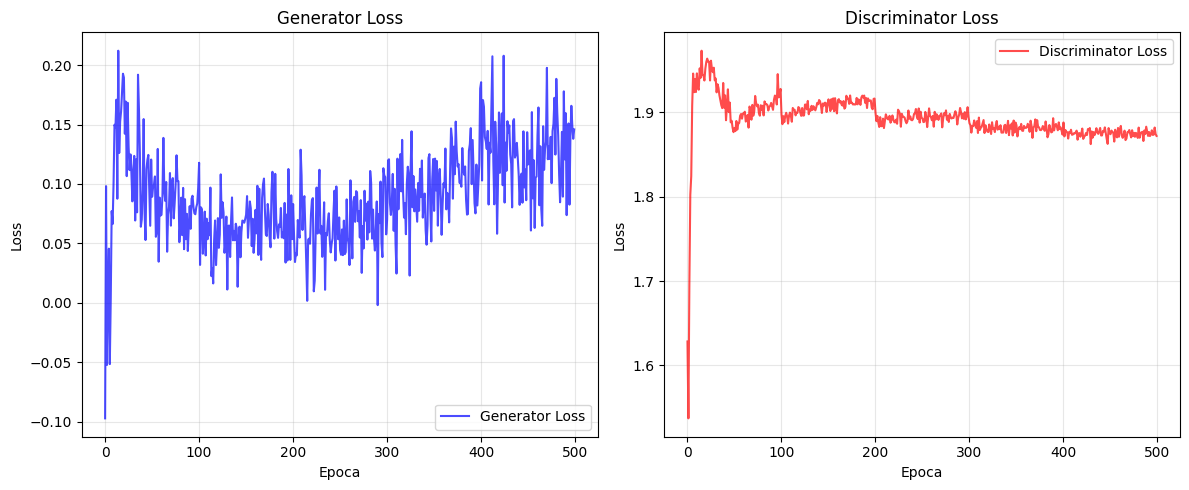

Grafico salvato in ./dcgan_advanced_img/loss_curves.png


In [13]:
# ============================================================================
# VISUALIZZAZIONE DELLE LOSS
# ============================================================================

plt.figure(figsize=(12, 5))

# Loss del Generator
plt.subplot(1, 2, 1)
plt.plot(g_losses, label='Generator Loss', color='blue', alpha=0.7)
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.title('Generator Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss del Discriminator
plt.subplot(1, 2, 2)
plt.plot(d_losses, label='Discriminator Loss', color='red', alpha=0.7)
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.title('Discriminator Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{folder_path}/loss_curves.png", dpi=150)
plt.show()

print(f"Grafico salvato in {folder_path}/loss_curves.png")

## Analisi dei Risultati: Curve di Loss

Analizziamo le curve di loss ottenute dopo 500 epoche di training per valutare la qualità e la stabilità del processo di apprendimento.

---

### Generator Loss (Grafico Blu)

| Metrica | Valore Osservato |
|---------|------------------|
| **Range** | -0.10 ÷ 0.20 |
| **Media** | ~0.05 - 0.10 |
| **Varianza** | Alta (oscillazioni frequenti) |
| **Trend** | Stabile, nessuna crescita indefinita |

#### Interpretazione:
- **La G Loss NON cresce indefinitamente** - segno che il Generator sta imparando
- **Valori bassi** (~0.05-0.10) indicano che D assegna score positivi alle fake
- **Le oscillazioni sono normali** nelle GAN: il "gioco" tra G e D causa fluttuazioni
- **Bounded nel range [-0.1, 0.2]** - training stabile senza divergenza

---

### Discriminator Loss (Grafico Rosso)

| Metrica | Valore Osservato |
|---------|------------------|
| **Valore iniziale** | ~1.6 |
| **Convergenza** | Rapida salita a ~1.9 (prime 50 epoche) |
| **Valore stabile** | ~1.87 - 1.90 |
| **Varianza** | Bassa dopo stabilizzazione |

#### Interpretazione:
- **D Loss alta (~1.9)** indica che il Discriminator fatica a distinguere real da fake
- **NON scende a 0** - D non sta "vincendo" troppo facilmente
- **Stabilizzazione rapida** - le tecniche di regolarizzazione funzionano
- **Bassa varianza** dopo epoca 100 - training equilibrato

---

### Confronto con i Valori Attesi

| Metrica | Valore Atteso | Valore Ottenuto | Valutazione |
|---------|---------------|-----------------|-------------|
| G Loss | Stabile, non crescente | Oscilla in [-0.1, 0.2] | Ottimo |
| D Loss | ~1.2 - 1.5 | ~1.87 - 1.90 | Leggermente alto |
| Equilibrio | Entrambe bounded | Sì | Ottimo |

#### Perché la D Loss è più alta del previsto?

La D Loss (~1.9) è leggermente superiore al range tipico (1.2-1.5). Questo è dovuto alla **R1 Gradient Penalty**:

La penalità R1 **aumenta intenzionalmente** la loss del Discriminator per impedirgli di creare superfici di decisione troppo ripide. Questo è un **comportamento desiderato**, non un problema.

---

### Diagnosi Finale

| Indicatore | Status | Commento |
|------------|--------|----------|
| Mode Collapse | Assente | G Loss non costante, varietà nelle immagini |
| D troppo forte | Assente | D Loss non scende a 0 |
| G troppo forte | Assente | G Loss non va a 0 costante |
| Divergenza | Assente | Entrambe le loss bounded |
| **Equilibrio** | **Raggiunto** | Training stabile e bilanciato |

### Conclusione

Le curve di loss confermano che il training con **DiffAugment + R1 + TTUR bilanciato** ha prodotto un **equilibrio dinamico stabile**. Le tecniche di stabilizzazione hanno funzionato correttamente:
- L'Instance Noise ha prevenuto il D troppo sicuro nelle prime epoche
- La R1 Penalty mantiene i gradienti del D sotto controllo (D Loss ~1.9)
- Il TTUR bilanciato ha permesso a G e D di co-evolvere senza che uno domini l'altro

## Generazione di Nuove Immagini

Ora che il training è completato, possiamo usare il Generator come una "macchina per creare fiori". Il Generator ha imparato a mappare punti nello spazio latente a immagini realistiche.

---

### Il Processo di Generazione

```
Rumore z ~ N(0,1)  →  Generator  →  Immagine [-1,1]  →  Denormalizzazione  →  Immagine [0,1]
   (128,)              G(z)           (3,128,128)                              (3,128,128)
```

#### Step 1: Campionamento dallo Spazio Latente

```python
z = torch.randn(num_images, z_dimension, 1, 1)
```

#### Step 2: Modalità Valutazione

```python
G.eval()
```

Mette il Generator in **evaluation mode**:
- **BatchNorm**: usa media e varianza calcolate durante il training (running statistics), non quelle del batch corrente
- **Dropout**: disattivato (se presente)

Questo garantisce output **deterministici**: lo stesso z produce sempre la stessa immagine.

#### Step 3: Generazione Senza Gradienti

```python
with torch.no_grad():
    fake_images = G(z)
```

`torch.no_grad()` disabilita il calcolo dei gradienti:
- **Risparmio memoria**: non serve allocare spazio per il grafo computazionale
- **Velocità**: ~20-30% più veloce senza tracking dei gradienti
- **Inferenza pura**: non stiamo trainando, solo generando

#### Step 4: Denormalizzazione

```python
images = (fake_images + 1) / 2  # Da [-1,1] a [0,1]
images = images.clamp(0, 1)     # Sicurezza: forza nel range valido
```

La `clamp` è una precauzione: in teoria l'output di Tanh è già in [-1,1], ma errori numerici potrebbero produrre valori leggermente fuori range.

---

### Qualità vs Diversità

Un buon Generator deve bilanciare:

| Metrica | Descrizione | Problema se troppo bassa |
|---------|-------------|--------------------------|
| **Qualità** | Immagini realistiche e dettagliate | Immagini sfocate o con artefatti |
| **Diversità** | Varietà nelle immagini generate | Mode collapse: tutte le immagini simili |

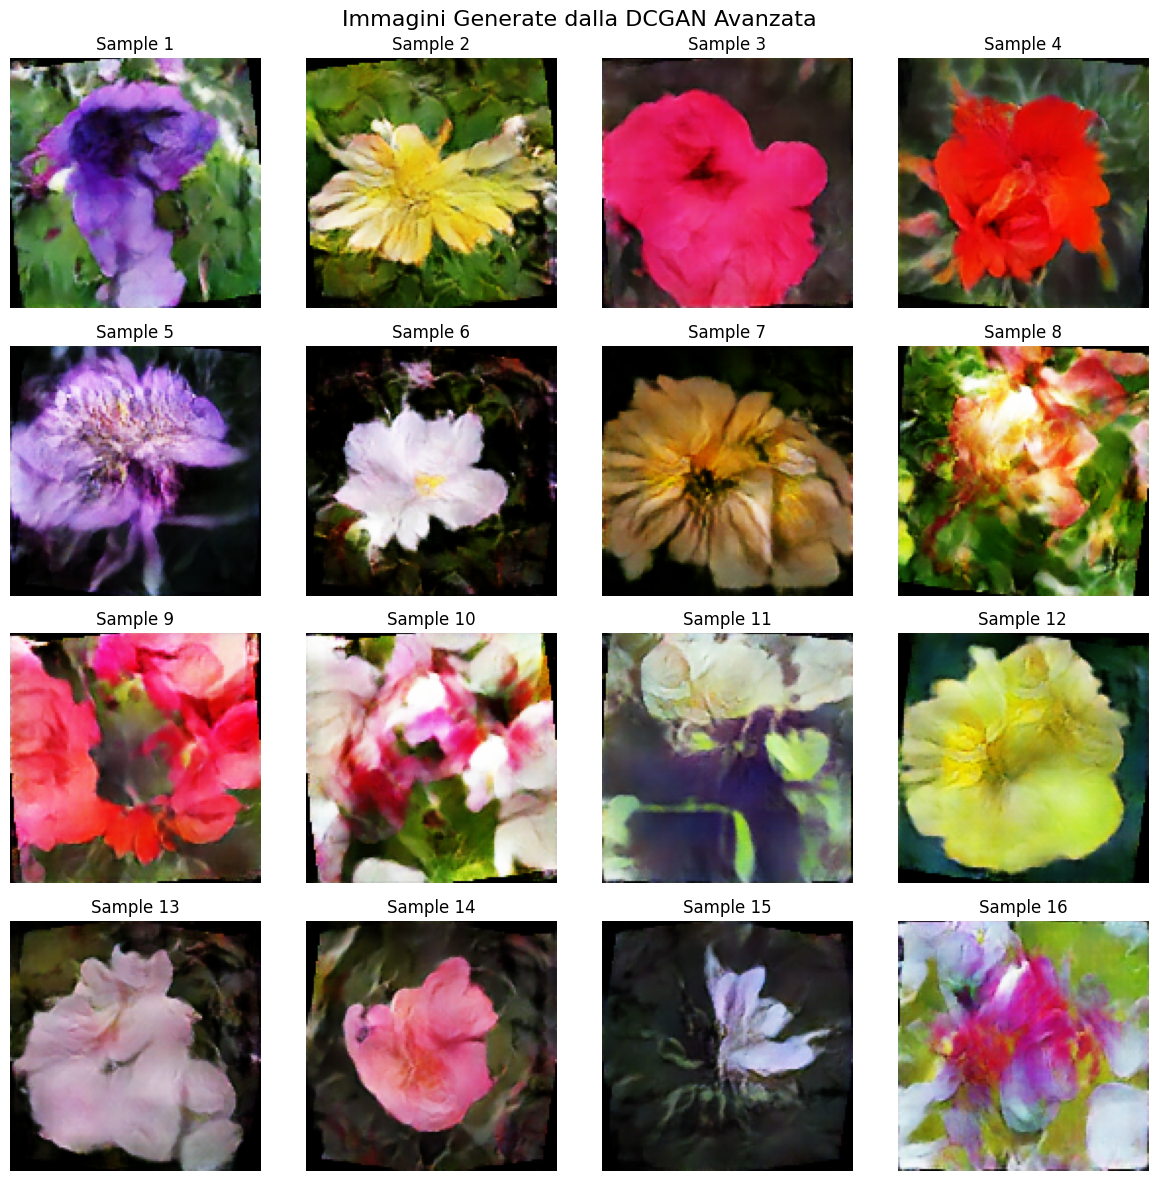

Immagini salvate in ./dcgan_advanced_img/generated_samples.png


In [14]:
# ============================================================================
# GENERAZIONE DI NUOVE IMMAGINI
# ============================================================================

# Mettiamo il Generator in modalità valutazione
G.eval()

# Numero di immagini da generare
num_images = 16

# Genera vettore di rumore casuale
noise = torch.randn(num_images, z_dimension, 1, 1, device=device)

# Genera le immagini (senza calcolare gradienti)
with torch.no_grad():
    fake_images = G(noise).cpu()

# Denormalizza da [-1, 1] a [0, 1]
fake_images_denorm = (fake_images + 1) / 2
fake_images_denorm = fake_images_denorm.clamp(0, 1)

# Visualizza le immagini in una griglia 4x4
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Immagini Generate dalla DCGAN Avanzata', fontsize=16)

for idx, ax in enumerate(axes.flat):
    # Converti da (C, H, W) a (H, W, C) per matplotlib
    img = fake_images_denorm[idx].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Sample {idx+1}')

plt.tight_layout()
plt.savefig(f"{folder_path}/generated_samples.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Immagini salvate in {folder_path}/generated_samples.png")

## Interpolazione nello Spazio Latente

Una delle proprietà più affascinanti delle GAN ben addestrate è che lo **spazio latente è semanticamente strutturato**: punti vicini producono immagini simili, e il movimento nello spazio corrisponde a trasformazioni graduali nell'immagine.

---

### Perché l'Interpolazione è Importante?

L'interpolazione ci dice molto sulla qualità del Generator:

| Comportamento | Significato |
|---------------|-------------|
| Transizioni smooth | Lo spazio latente è ben strutturato |
| Salti bruschi | Spazio latente "bucato" o mode collapse |
| Immagini intermedie realistiche | G ha imparato una rappresentazione continua |
| Artefatti nelle transizioni | G ha memorizzato esempi specifici |

---

### Cosa Cercare nei Risultati

Osservando le immagini interpolate da $z_1$ a $z_2$:

1. **Colore**: dovrebbe cambiare gradualmente (es. da rosa a giallo)
2. **Forma**: i petali dovrebbero trasformarsi smoothly
3. **Sfondo**: dovrebbe fondersi senza salti
4. **Nessuna immagine "rotta"**: tutte le immagini intermedie devono essere fiori riconoscibili

---

### Applicazioni dell'Interpolazione

| Applicazione | Descrizione |
|--------------|-------------|
| **Morphing** | Creare video di transizione tra due immagini |
| **Data Augmentation** | Generare varianti intermedie per training |
| **Controllo creativo** | Esplorare lo spazio delle possibilità |
| **Debugging** | Verificare che G non abbia mode collapse |

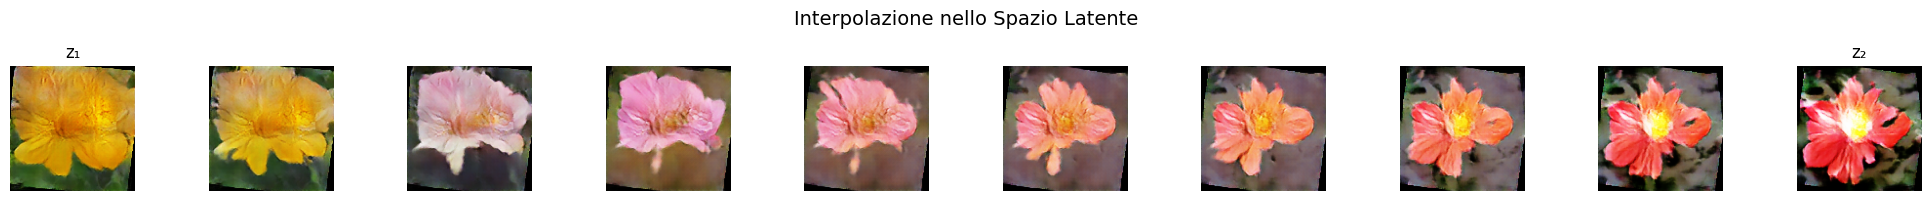

Interpolazione salvata in ./dcgan_advanced_img/latent_interpolation.png


In [15]:
# ============================================================================
# INTERPOLAZIONE NELLO SPAZIO LATENTE
# ============================================================================

def interpolate_latent(z1, z2, num_steps=10):
    """
    Interpola linearmente tra due vettori latenti.
    """
    alphas = torch.linspace(0, 1, num_steps)
    interpolations = []
    for alpha in alphas:
        z_interp = (1 - alpha) * z1 + alpha * z2
        interpolations.append(z_interp)
    return torch.stack(interpolations)

# Genera due vettori latenti casuali
z1 = torch.randn(1, z_dimension, 1, 1, device=device)
z2 = torch.randn(1, z_dimension, 1, 1, device=device)

# Numero di passi di interpolazione
num_steps = 10

# Crea le interpolazioni
z_interp = interpolate_latent(z1.squeeze(), z2.squeeze(), num_steps)
z_interp = z_interp.unsqueeze(-1).unsqueeze(-1)  # Aggiungi dimensioni spaziali

# Genera le immagini
G.eval()
with torch.no_grad():
    interp_images = G(z_interp).cpu()

# Denormalizza
interp_images_denorm = (interp_images + 1) / 2
interp_images_denorm = interp_images_denorm.clamp(0, 1)

# Visualizza
fig, axes = plt.subplots(1, num_steps, figsize=(20, 2))
fig.suptitle('Interpolazione nello Spazio Latente', fontsize=14)

for idx, ax in enumerate(axes):
    img = interp_images_denorm[idx].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.axis('off')
    if idx == 0:
        ax.set_title('z₁')
    elif idx == num_steps - 1:
        ax.set_title('z₂')

plt.tight_layout()
plt.savefig(f"{folder_path}/latent_interpolation.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Interpolazione salvata in {folder_path}/latent_interpolation.png")

## Interpretazione dei Risultati dell'Interpolazione

Analizziamo l'interpolazione generata dal nostro modello per valutare la qualità dello spazio latente appreso.

---

### Analisi dell'Interpolazione z₁ → z₂

L'immagine mostra una transizione in **10 step** tra due punti dello spazio latente:

| Posizione | Descrizione |
|-----------|-------------|
| **z₁ (sinistra)** | Fiore giallo-arancione con sfondo verde |
| **z₂ (destra)** | Fiore rosso-corallo con sfondo scuro |

---

### Osservazioni Positive

#### 1. Transizione del Colore: Smooth
Il colore dei petali cambia **gradualmente**:
```
Giallo → Arancione → Rosa → Salmone → Corallo → Rosso
```
Non ci sono salti bruschi di colore, indicando che il Generator ha imparato una rappresentazione **continua** del colore.

#### 2. Trasformazione della Forma: Coerente
La struttura del fiore si trasforma progressivamente:
- I petali cambiano forma gradualmente
- Il centro del fiore (stami) rimane riconoscibile durante tutta la transizione
- La struttura complessiva resta quella di un fiore in ogni frame

#### 3. Sfondo: Transizione Naturale
Lo sfondo passa dal verde al marrone/scuro in modo fluido, dimostrando che il modello ha imparato a generare sfondi coerenti con il soggetto.

#### 4. Nessuna Immagine "Rotta"
**Tutte le 10 immagini sono fiori riconoscibili** - non ci sono:
- Artefatti visivi
- Forme distorte
- Mescolanze innaturali

---

### Conclusione

L'interpolazione dimostra che la DCGAN avanzata con **DiffAugment + R1 + TTUR bilanciato** ha appreso uno spazio latente:

1. **Continuo**: punti vicini in z producono immagini simili
2. **Smooth**: le transizioni sono graduali e naturali  
3. **Semanticamente organizzato**: attributi come colore e forma variano in modo coerente
4. **Senza mode collapse**: il modello genera varietà di fiori diversi

Questi risultati confermano che le tecniche di stabilizzazione implementate hanno permesso un training **equilibrato e di qualità**.